# Comparison of Repair Algorithms
This notebook aggregates experiment results and compares the performance of various repair algorithms across multiple datasets.

In [19]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Setup
results_dir = Path('../results')
datasets = ['adult', 'census', 'compas', 'tax']
algorithms = ['ilp_marginals', 'ilp_no_marginals', 'classic_vc', 'vanilla_vc', 'weighted_vc']

def load_results():
    data = []
    for folder in os.listdir(results_dir):
        folder_path = results_dir / folder
        if not folder_path.is_dir():
            continue
            
        for file in os.listdir(folder_path):
            if not file.endswith('.json'):
                continue
                
            with open(folder_path / file, 'r') as f:
                res = json.load(f)
                
            meta = res.get('metadata', {})
            synth_params = meta.get('synthesizer_params', {})
            
            # Extract Dataset name from folder name (grid_dataset_algorithm)
            ds_name = 'unknown'
            for d in datasets:
                if f"grid_{d}" in folder:
                    ds_name = d
                    break

            # Extract Algorithm name
            algo_name = folder.split(f"grid_{ds_name}_")[-1]
            
            row = {
                'Dataset': ds_name,
                'Algorithm': algo_name,
                'Iterations': synth_params.get('num_of_iterations', 0),
                'Deletion Ratio': res.get('deletion_ratio', {}).get('ratio', 0),
                'Avg TVD': res.get('tvd_2way', {}).get('repaired_avg', 0),
                'Marginal Error': res.get('marginals_error', {}).get('repaired_avg', 0),
                'Repair Time (s)': res.get('runtimes', {}).get('repairing', 0),
                'Loss Function': res.get('loss_function', {}).get('repaired', 0).get('total', 0),
                'Size Loss Function': res.get('loss_function', {}).get('repaired', 0).get('size_component', 0),
                'Stat Loss Function': res.get('loss_function', {}).get('repaired', 0).get('marginal_component', 0)
            }
            
            # Add ML accuracies
            ml_res = res.get('ml_accuracy', {}).get('repaired', {})
            for model, acc in ml_res.items():
                row[f'ML_{model}'] = acc
                
            data.append(row)
            
    return pd.DataFrame(data)

df = load_results()
df = df[df['Dataset'] != 'unknown']
df = df.sort_values(['Dataset', 'Algorithm', 'Iterations'])
df.head()

,Dataset,Algorithm,Iterations,Deletion Ratio,Avg TVD,Marginal Error,Repair Time (s),Loss Function,Size Loss Function,Stat Loss Function,ML_logistic_regression,ML_random_forest,ML_mlp
1,adult,classic_vc,10,0.000409,0.000179,0.908915,0.646188,0.000236,0.000409,0.000062,0.550244,0.974366,0.576082
2,adult,classic_vc,10,0.000409,0.000175,0.606168,0.738779,0.000235,0.000409,0.000061,0.550203,0.974305,0.576655
3,adult,classic_vc,10,0.000409,0.000179,0.966817,0.663299,0.000233,0.000409,0.000057,0.550203,0.974346,0.576246
8,adult,classic_vc,50,0.002047,0.000526,0.605277,3.064117,0.001055,0.002047,0.000062,0.550203,0.973568,0.574731
13,adult,classic_vc,50,0.002047,0.000498,0.830493,3.103625,0.001054,0.002047,0.000061,0.550264,0.973629,0.574772


In [5]:
# Define visual styles for algorithms
algo_styles = {
    'ilp_marginals': {'marker': 'o', 'lw': 4.0, 'color': '#d62728', 'ms': 12},
    'ilp_no_marginals': {'marker': 's', 'lw': 3.0, 'color': '#1f77b4', 'ms': 10},
    'classic_vc': {'marker': '^', 'lw': 2.0, 'color': '#ff7f0e', 'ms': 10},
    'vanilla_vc': {'marker': 'v', 'lw': 1.5, 'color': '#2ca02c', 'ms': 10},
    'weighted_vc': {'marker': 'D', 'lw': 2.5, 'color': '#9467bd', 'ms': 9}
}

def plot_measurement(df, measurement, log_y=False):
    # Use 2x2 grid for larger subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle(f'Comparison: {measurement}', fontsize=24, y=1.02)
    
    axes_flat = axes.flatten()
    
    for i, ds in enumerate(datasets):
        ax = axes_flat[i]
        ds_df = df[df['Dataset'] == ds]
        
        for algo in algorithms:
            algo_df = ds_df[ds_df['Algorithm'] == algo]
            if algo_df.empty: continue
            
            style = algo_styles.get(algo, {})
            ax.plot(algo_df['Iterations'], algo_df[measurement], 
                    label=algo, 
                    marker=style.get('marker'), 
                    linewidth=style.get('lw'),
                    color=style.get('color'),
                    markersize=style.get('ms'))
        
        ax.set_title(f'Dataset: {ds.upper()}', fontsize=18, fontweight='bold')
        ax.set_xlabel('Synthesizer Iterations', fontsize=14)
        ax.set_ylabel(measurement, fontsize=14)
        
        if log_y:
            ax.set_yscale('log')
            
        ax.grid(True, which="both", ls="--", alpha=0.6)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.legend(fontsize=12, loc='best', frameon=True, shadow=True)
            
    plt.tight_layout(pad=3.0)
    plt.show()

## 1. Deletion Ratio
Measures the fraction of tuples removed to satisfy all constraints.

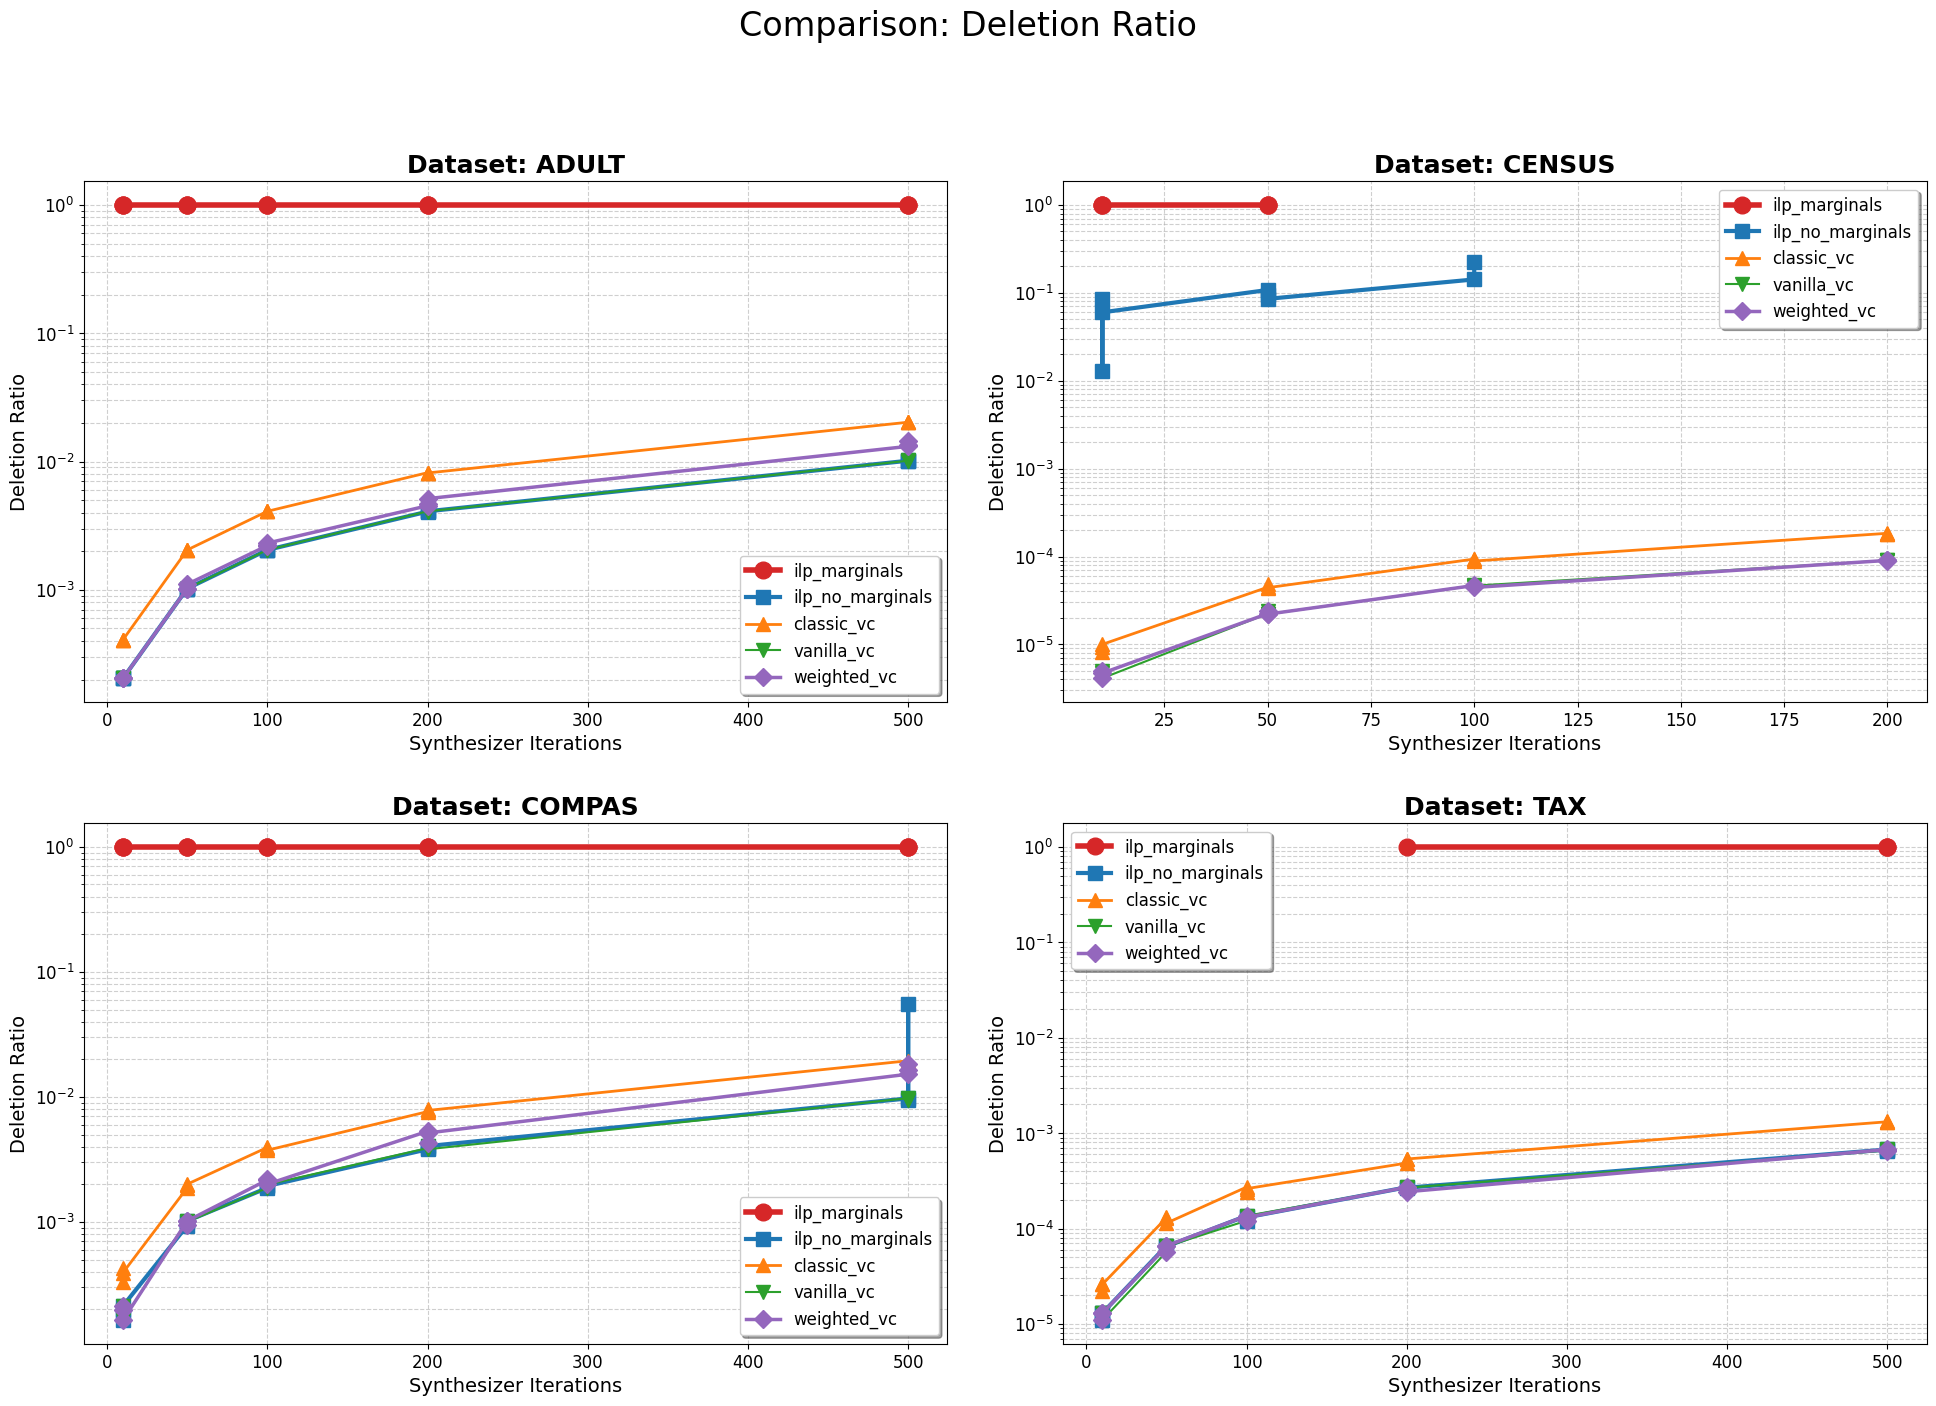

In [7]:
plot_measurement(df, 'Deletion Ratio',log_y=True)

## 2. Average TVD (Total Variation Distance)
Measures the distributional drift introduced by the repair.

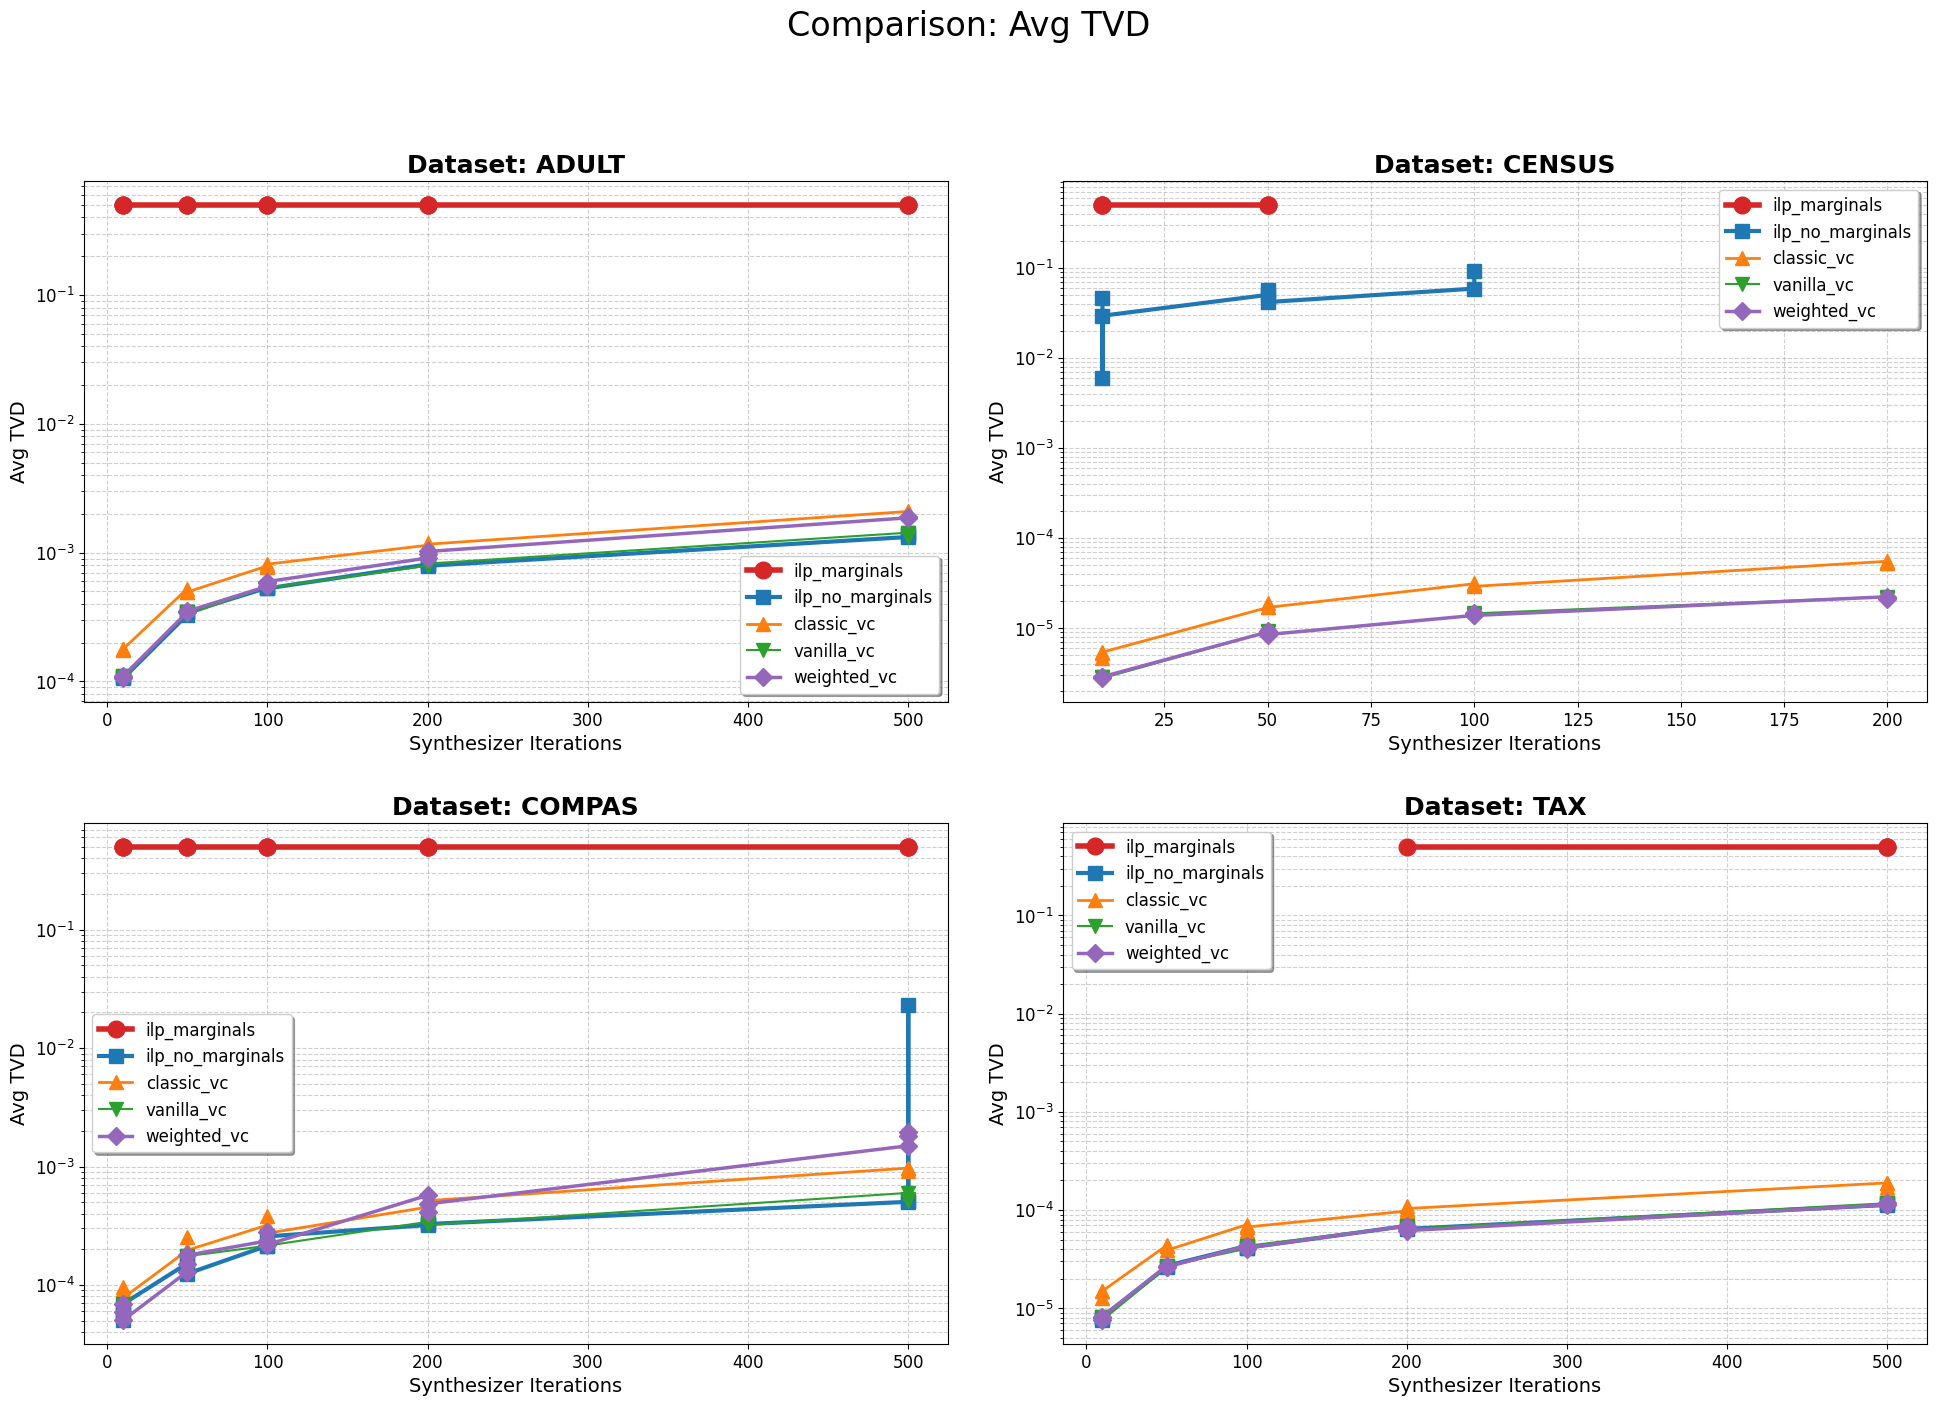

In [9]:
plot_measurement(df, 'Avg TVD',log_y=True)

## 3. Marginal Error
Measures how well the repaired data preserves the target marginals.

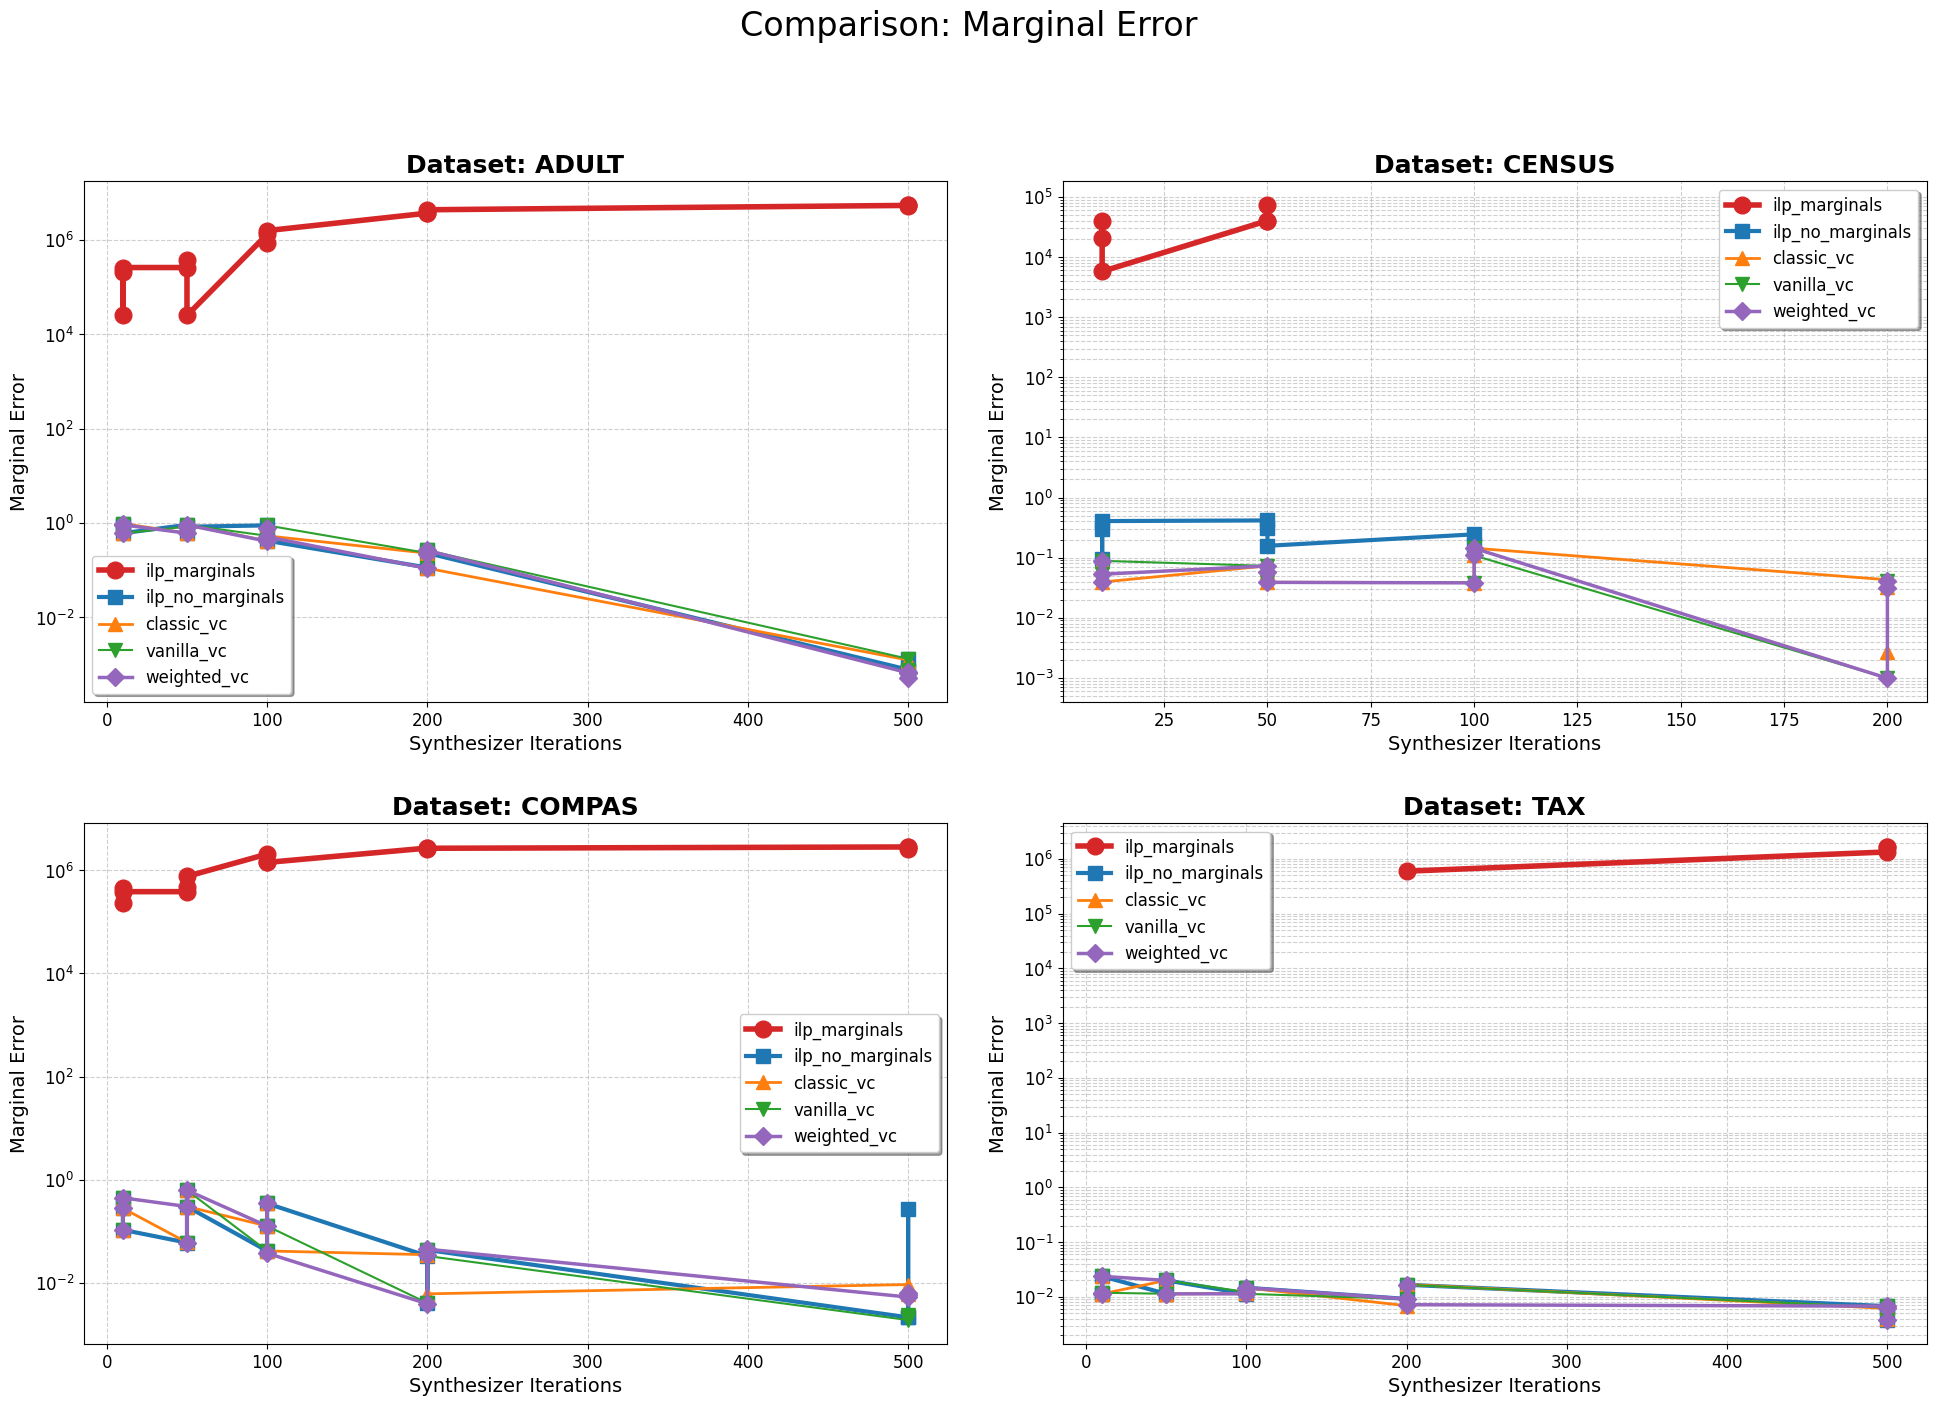

In [10]:
plot_measurement(df, 'Marginal Error', log_y=True)

## 4. Repair Time
Execution time of the repair algorithm in seconds.

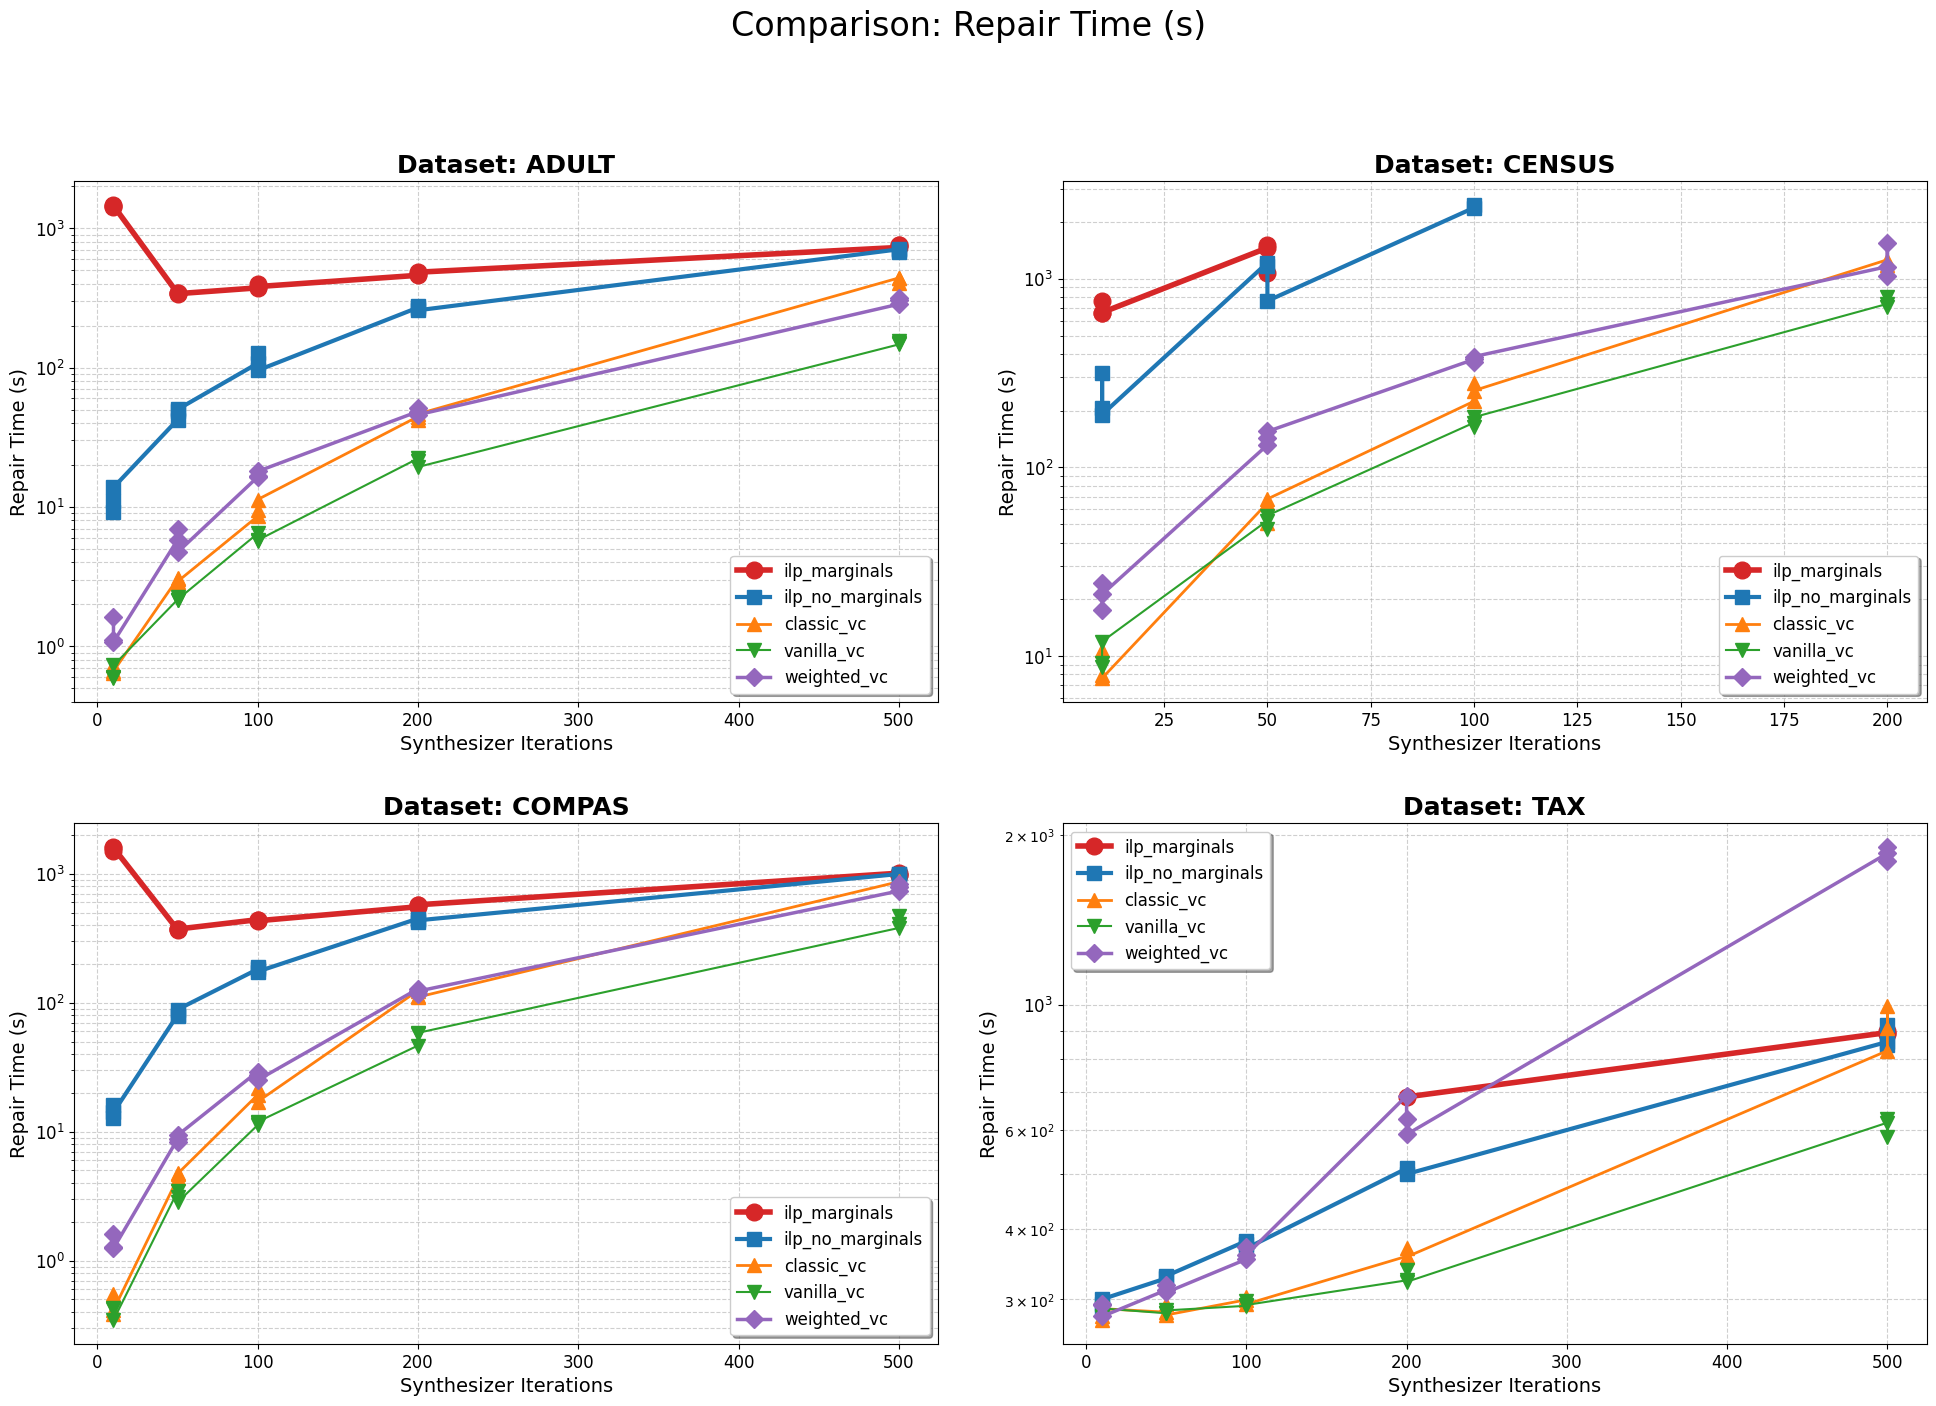

In [11]:
plot_measurement(df, 'Repair Time (s)', log_y=True)

## 5. ML Accuracy (Random Forest)
Downstream utility task performance.

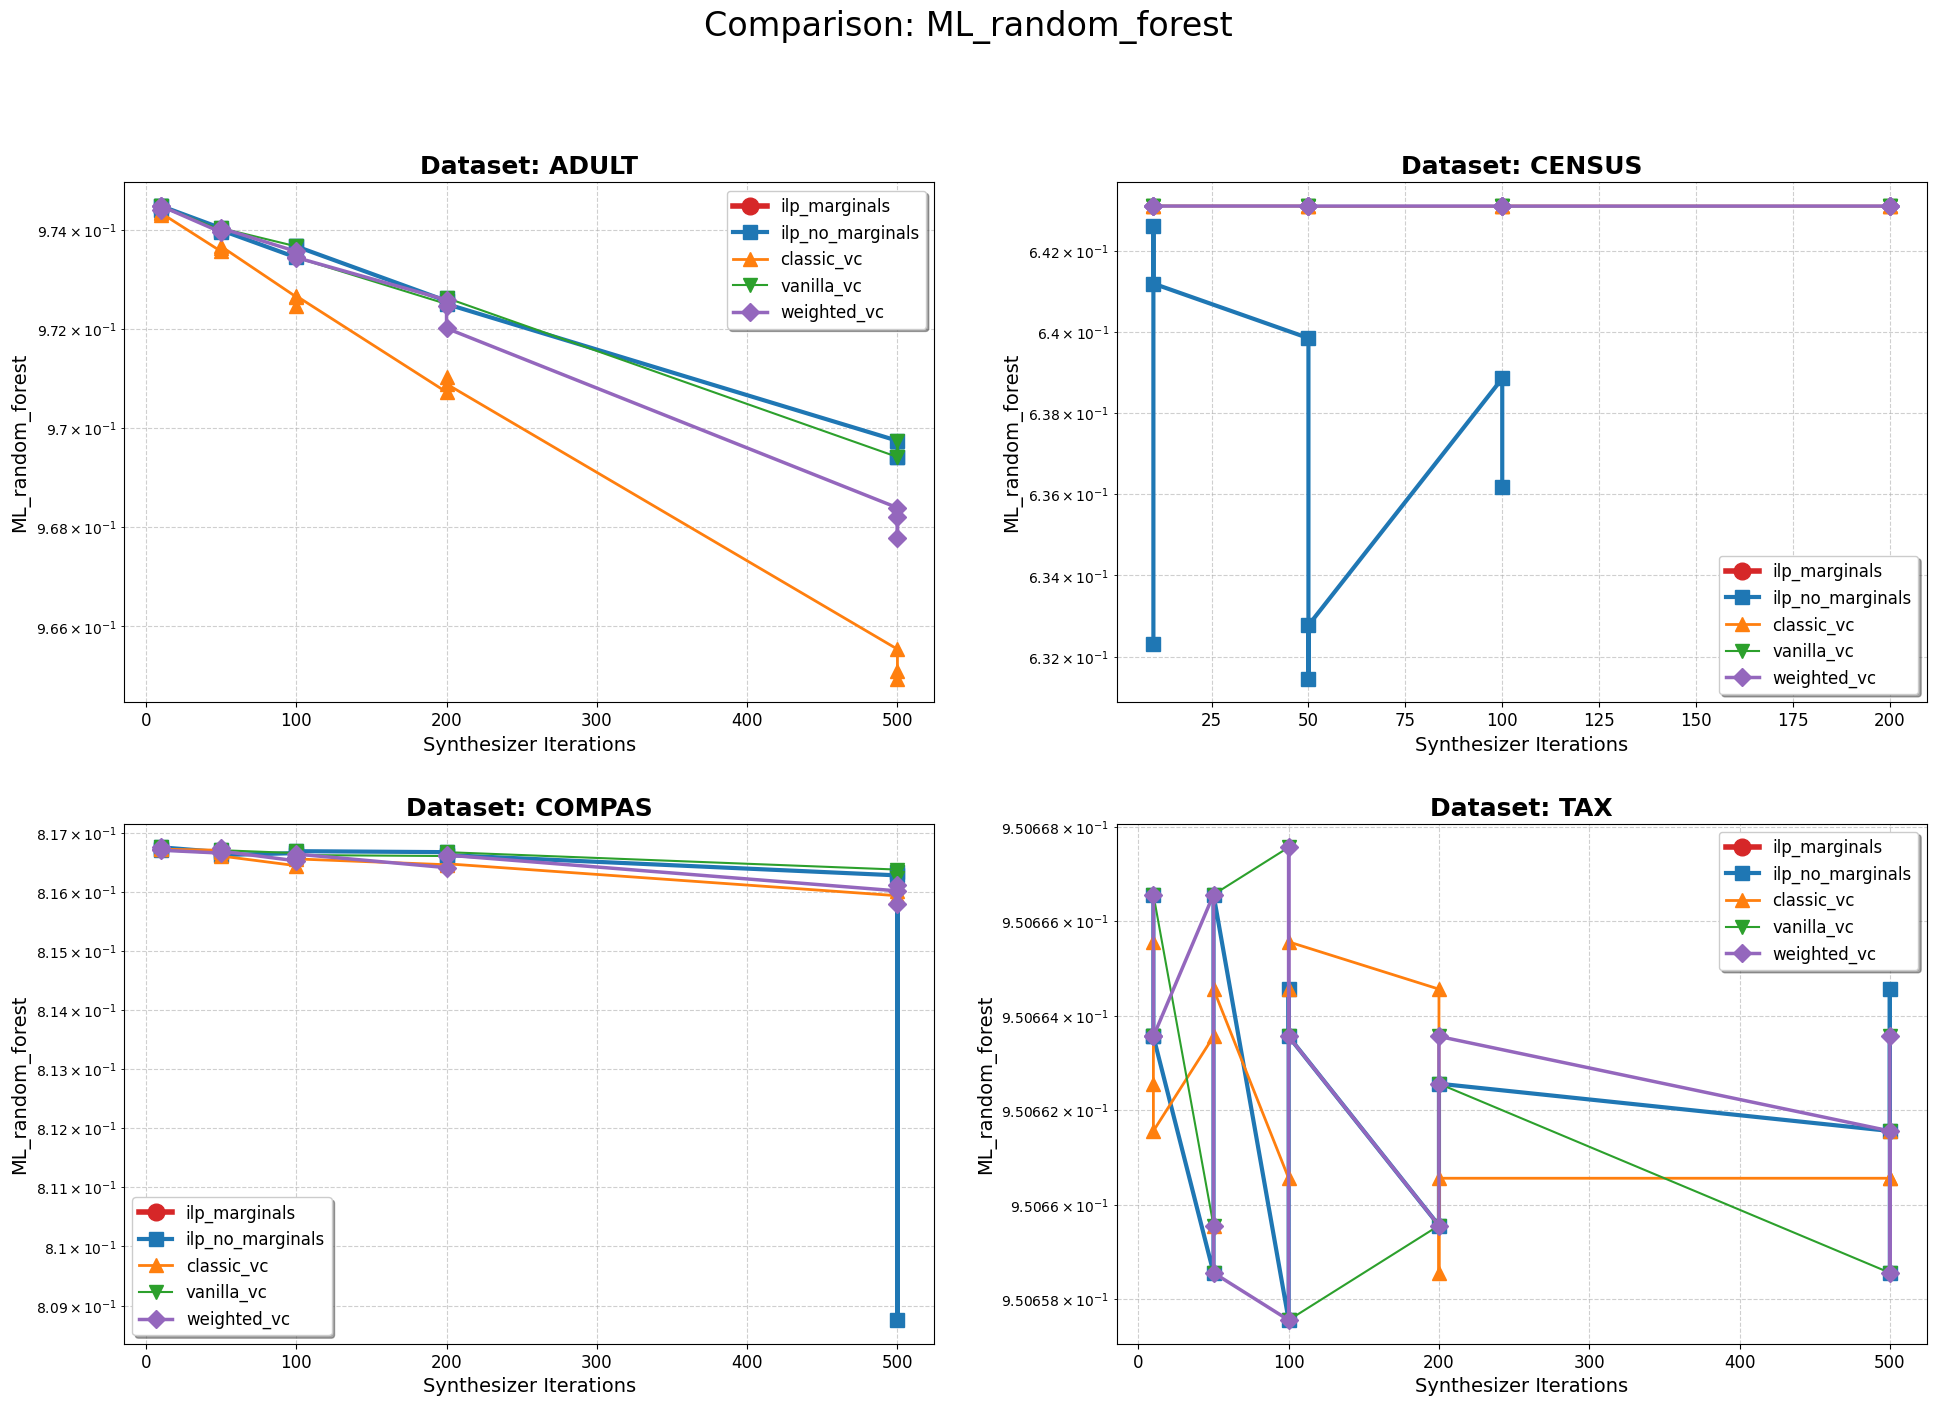

In [ ]:
plot_measurement(df, 'ML_random_forest',log_y=True)

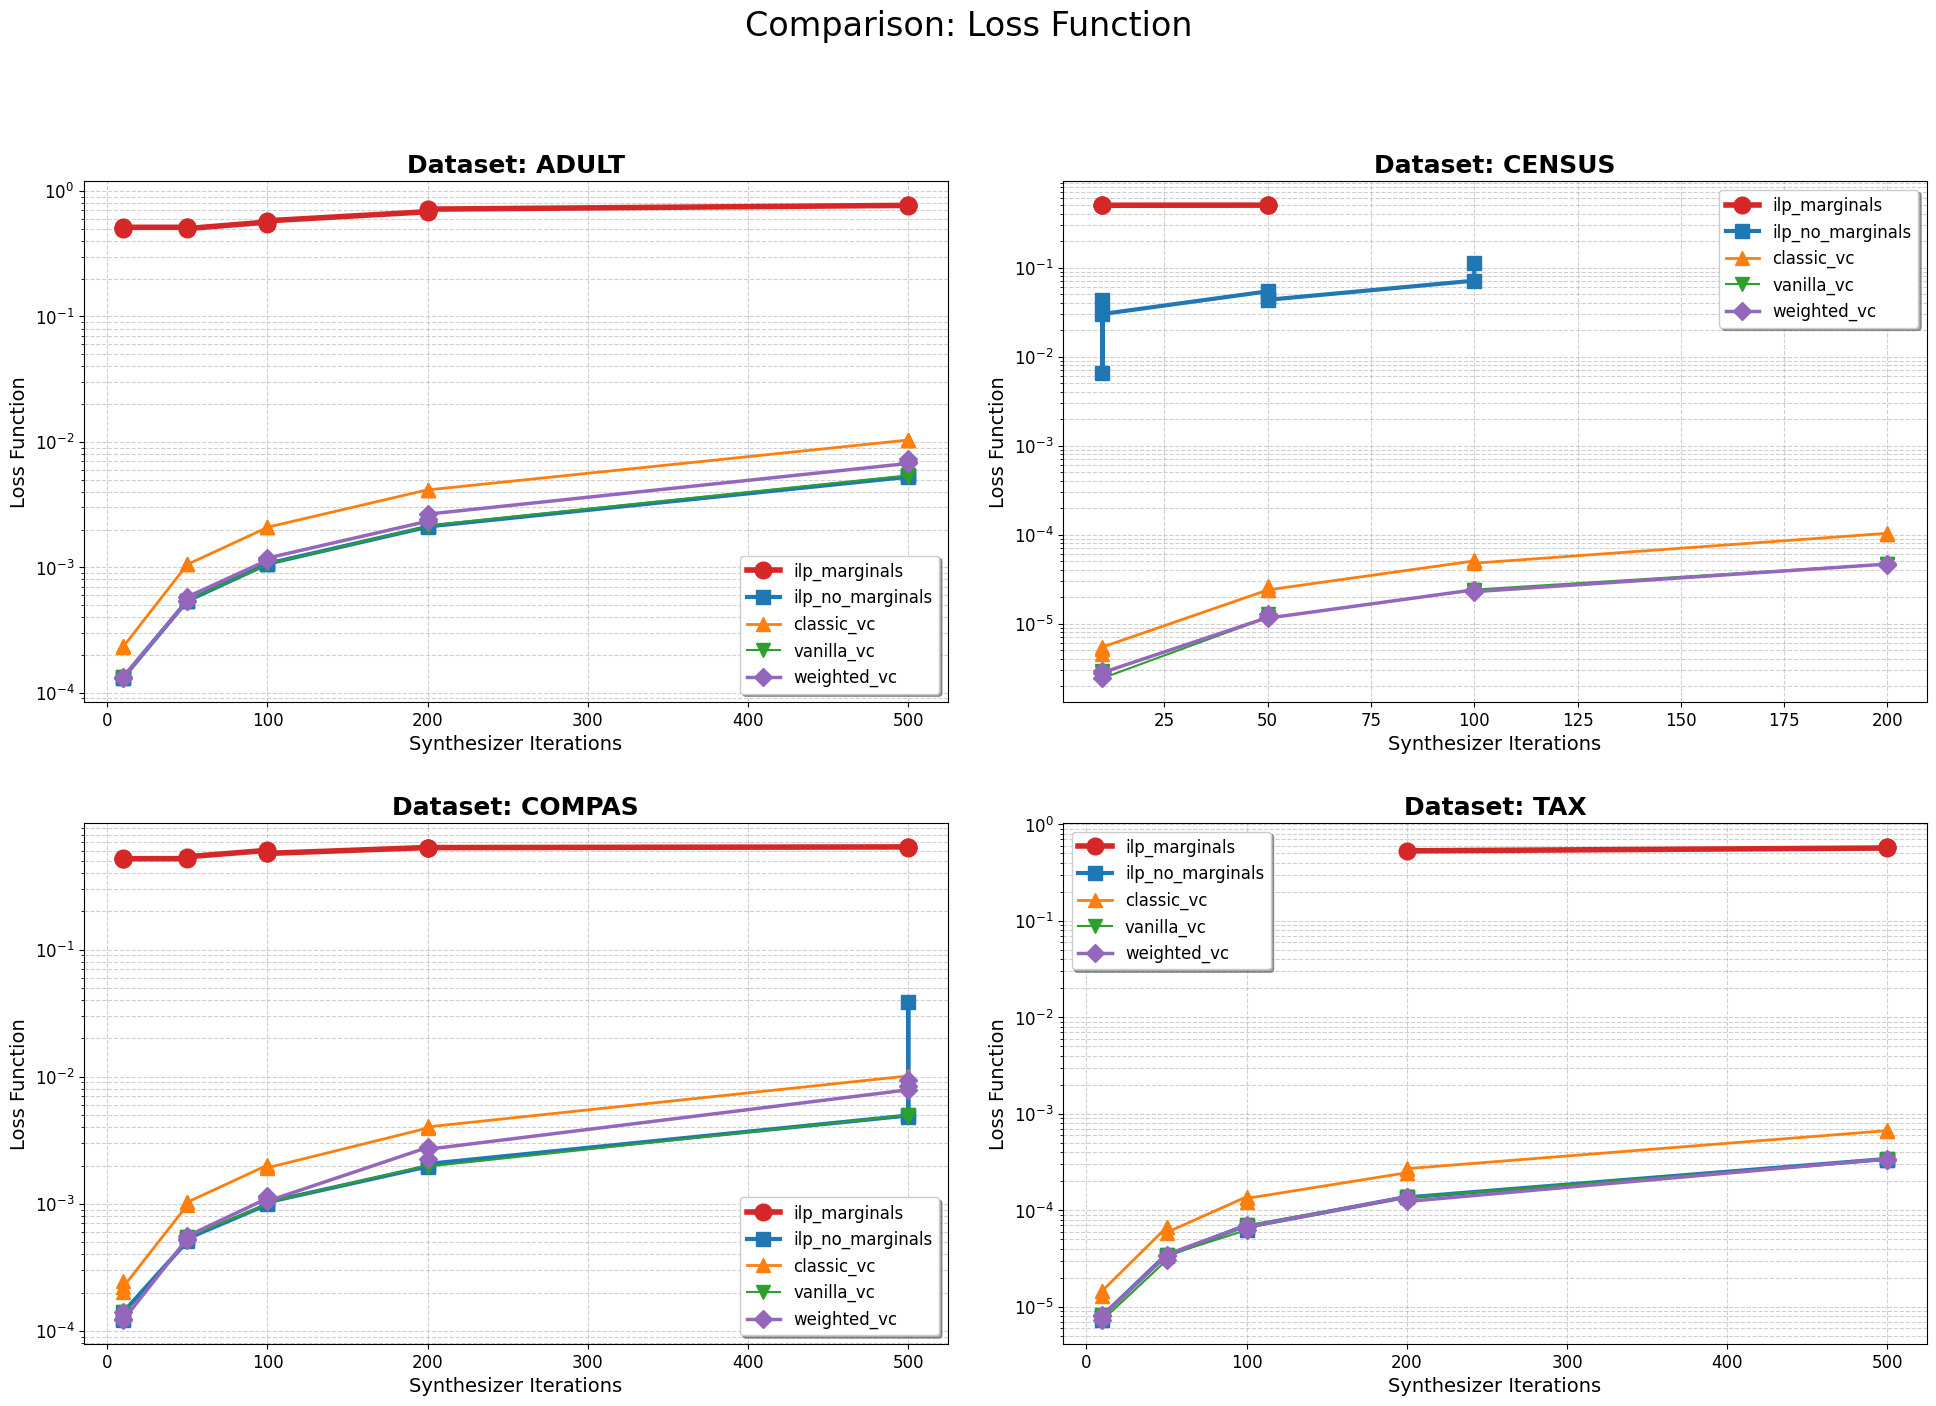

In [18]:
plot_measurement(df, 'Loss Function',log_y=True)

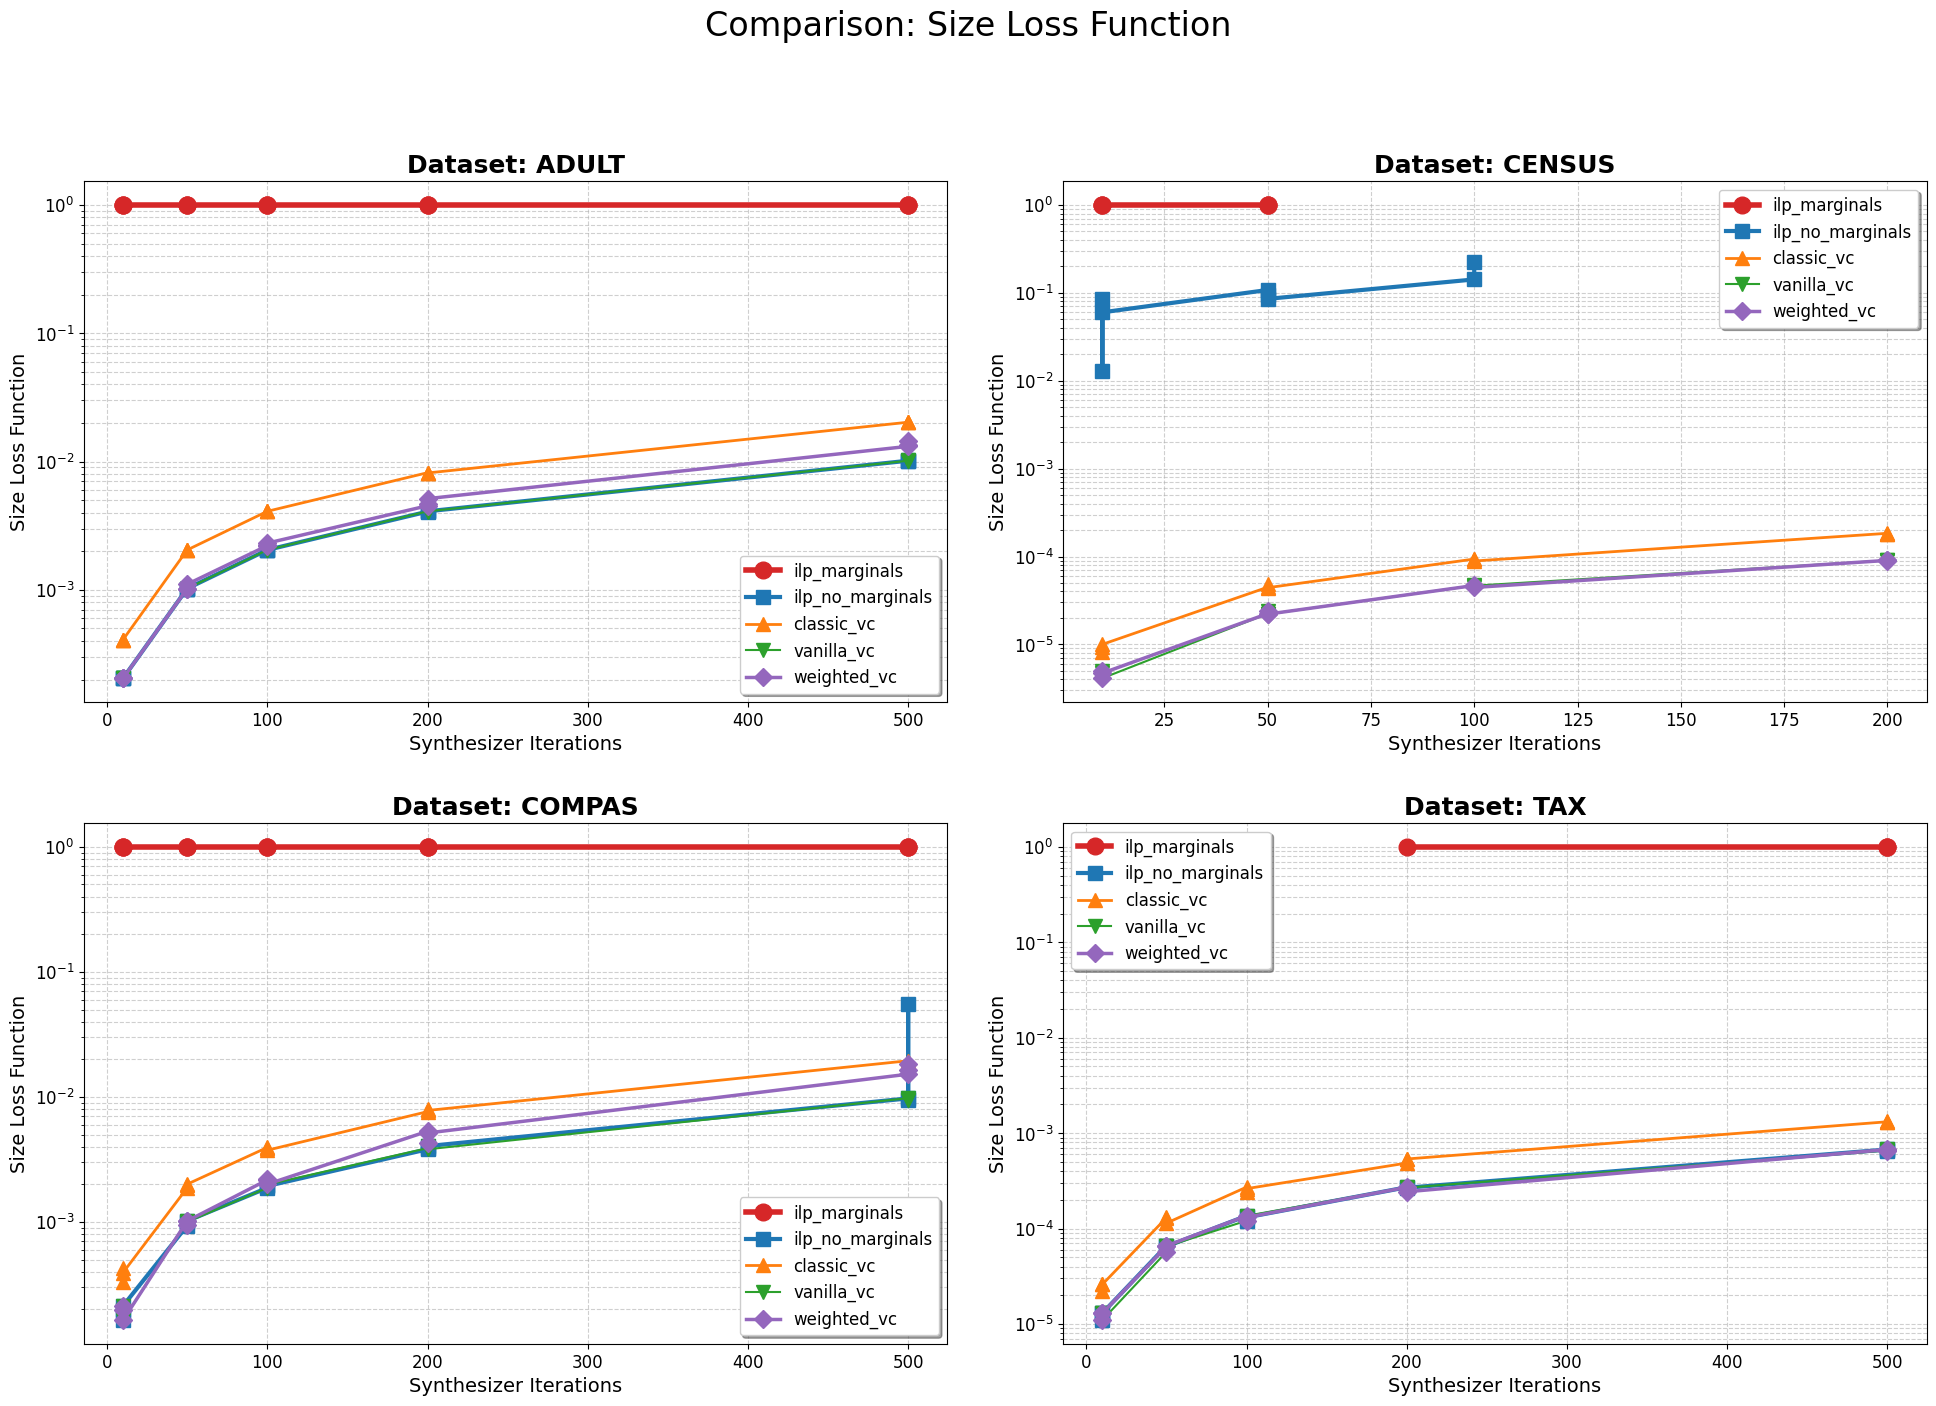

In [20]:
plot_measurement(df, 'Size Loss Function',log_y=True)

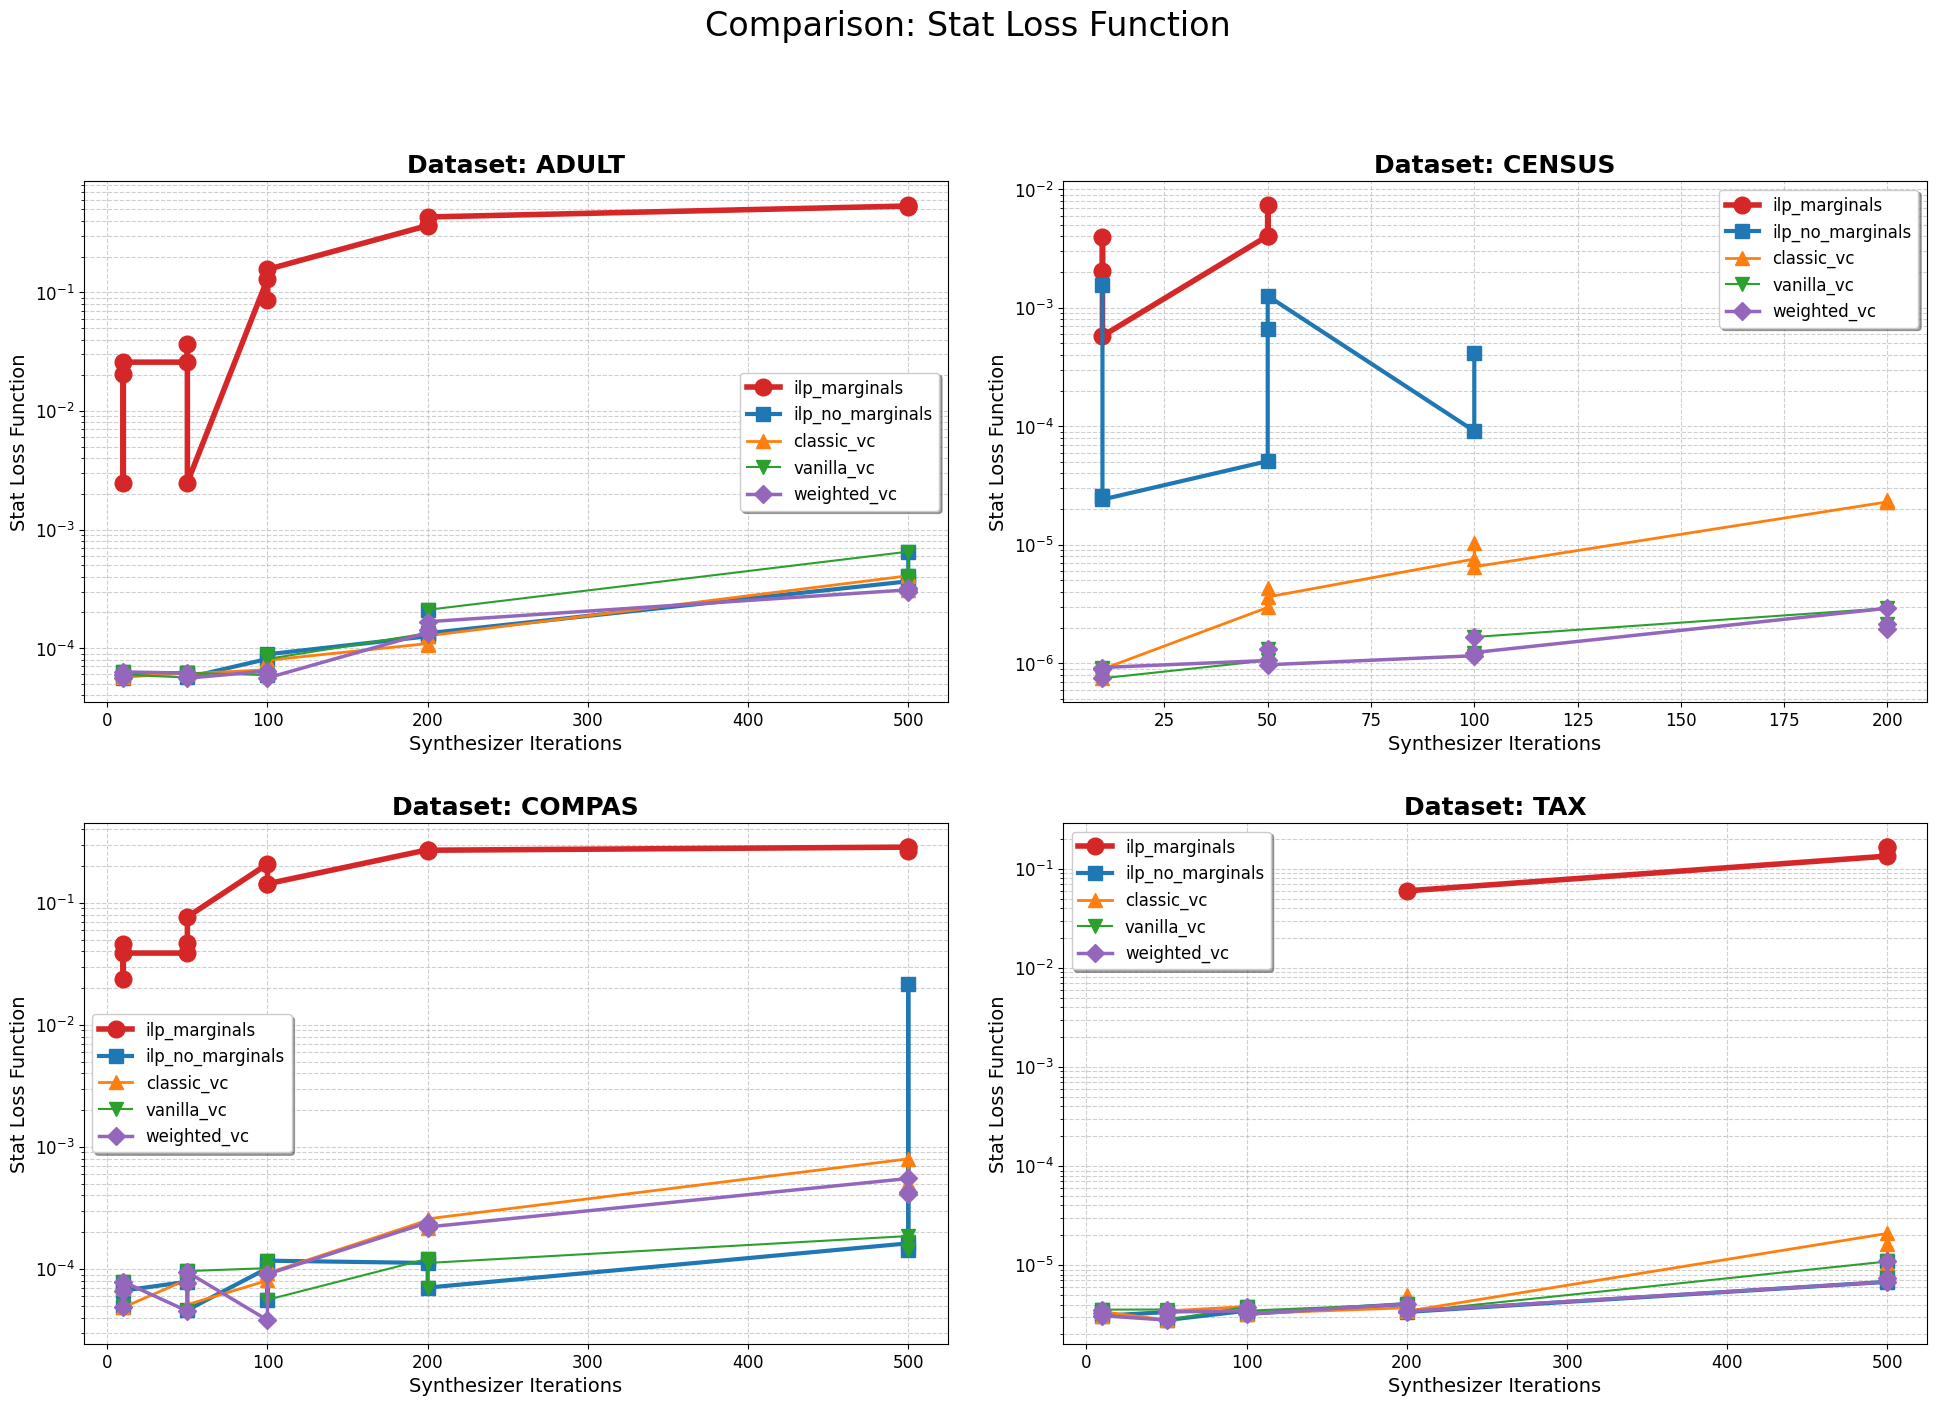

In [21]:
plot_measurement(df, 'Stat Loss Function',log_y=True)